# 📊 EDA Comparativo - EBLET People Analytics

## Objetivo
Análisis exploratorio comparativo de los 5 escenarios organizacionales:
- 🟢 Saludable
- 🟡 Estable
- 🟠 Riesgo Burnout
- 🔵 Riesgo Boreout
- 🔴 Crítico

## Contenido
1. Carga de datos
2. Estadísticos descriptivos por escenario
3. **6 Gráficos Comparativos**
4. Interpretación

In [ ]:
pip install pandas numpy matplotlib seaborn plotly scipy scikit-learn factor_analyzer statsmodels

In [14]:
pip install nbformat ipywidgets jupyter ipykernel plotly kaleido

  Using cached jupyter-1.1.1-py2.py3-none-any.whl.metadata (2.0 kB)
  Using cached notebook-7.6.0-py3-none-any.whl.metadata (10 kB)
  Using cached jupyter_console-6.6.3-py3-none-any.whl.metadata (5.8 kB)
  Using cached nbconvert-7.17.1-py3-none-any.whl.metadata (8.4 kB)
  Using cached jupyterlab-4.6.1-py3-none-any.whl.metadata (16 kB)
  Using cached async_lru-2.3.0-py3-none-any.whl.metadata (7.6 kB)
  Using cached httpx-0.28.1-py3-none-any.whl.metadata (7.1 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached jupyter_builder-1.0.2-py3-none-any.whl.metadata (7.7 kB)
  Using cached jupyter_lsp-2.3.1-py3-none-any.whl.metadata (1.8 kB)
  Using cached jupyter_server-2.20.0-py3-none-any.whl.metadata (8.5 kB)
  Using cached jupyterlab_server-2.28.0-py3-none-any.whl.metadata (5.9 kB)
  Using cached notebook_shim-0.2.4-py3-none-any.whl.metadata (4.0 kB)
  Using cached anyio-4.14.1-py3-none-any.whl.metadata (4.6 kB)
  Using cached certifi-2026.6.17-py3-none-any.whl.m

In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Configuración visual
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# =====================================================
# CONFIGURACIÓN DE RUTAS
# =====================================================

RAIZ_PROYECTO = r"C:\Users\torre\OneDrive\Escritorio\EBLET-People-Analytics\Python"

# Añadir src/ al path para imports
sys.path.insert(0, os.path.join(RAIZ_PROYECTO, "src"))

print(f"✅ Raíz del proyecto: {RAIZ_PROYECTO}")
print(f"✅ datasets/ existe: {os.path.exists(os.path.join(RAIZ_PROYECTO, 'datasets'))}")

# =====================================================
# CONFIGURACIÓN DE ESCENARIOS
# =====================================================

ESCENARIOS = ["saludable", "estable", "riesgo_burnout", "riesgo_boreout", "critico"]

COLORES = {
    "saludable": "#2ecc71",
    "estable": "#f1c40f",
    "riesgo_burnout": "#e67e22",
    "riesgo_boreout": "#3498db",
    "critico": "#e74c3c"
}

ETIQUETAS = {
    "saludable": "🟢 Saludable",
    "estable": "🟡 Estable",
    "riesgo_burnout": "🟠 Riesgo Burnout",
    "riesgo_boreout": "🔵 Riesgo Boreout",
    "critico": "🔴 Crítico"
}

# =====================================================
# CARGA DE DATASETS
# =====================================================

dfs = {}
for esc in ESCENARIOS:
    ruta = os.path.join(RAIZ_PROYECTO, f"datasets/{esc}/empleados.csv")
    dfs[esc] = pd.read_csv(ruta)
    dfs[esc]["escenario"] = esc
    dfs[esc]["escenario_label"] = ETIQUETAS[esc]
    print(f"✅ Cargado {esc}: {len(dfs[esc]):,} empleados")

# Dataset unificado
df_all = pd.concat(dfs.values(), ignore_index=True)

print(f"\n📊 TOTAL: {len(df_all):,} empleados en {len(ESCENARIOS)} escenarios")
print(f"📋 Columnas: {len(df_all.columns)}")
df_all.head()

✅ Raíz del proyecto: C:\Users\torre\OneDrive\Escritorio\EBLET-People-Analytics\Python
✅ datasets/ existe: True
✅ Cargado saludable: 2,500 empleados
✅ Cargado estable: 2,500 empleados
✅ Cargado riesgo_burnout: 2,500 empleados
✅ Cargado riesgo_boreout: 2,500 empleados
✅ Cargado critico: 2,500 empleados

📊 TOTAL: 12,500 empleados en 5 escenarios
📋 Columnas: 78


,empleado_id,empresa_id,nombre,ciudad,sector,tamano,cultura,escenario,burnout_base,boreout_base,...,kpi_contexto,burnout_agotamiento,burnout_cinismo,burnout_ineficacia,boreout_desinteres,boreout_falta_reto,boreout_infraocupacion,bienestar_satisfaccion,bienestar_autoeficacia,escenario_label
0,EMP_00000,SAL_036,saludable_Corp_36,Barcelona,Fintech,Pequeña,Colaborativa,saludable,2.0,1.8,...,4.000000,1.666667,1.333333,1.000000,1.000000,1.000000,1.000000,5.00,4.666667,🟢 Saludable
1,EMP_00001,SAL_022,saludable_Corp_22,Madrid,E-commerce,Micro,Colaborativa,saludable,2.0,1.8,...,4.000000,1.000000,1.333333,1.333333,1.666667,1.666667,1.333333,4.00,4.333333,🟢 Saludable
2,EMP_00002,SAL_032,saludable_Corp_32,Madrid,E-commerce,Grande,Colaborativa,saludable,2.0,1.8,...,4.333333,2.000000,1.666667,1.000000,2.000000,2.333333,1.666667,4.50,4.000000,🟢 Saludable
3,EMP_00003,SAL_020,saludable_Corp_20,Barcelona,Consultoría,Pequeña,Exigente,saludable,2.0,1.8,...,4.333333,1.666667,1.666667,2.000000,2.000000,1.666667,2.000000,3.75,4.333333,🟢 Saludable
4,EMP_00004,SAL_043,saludable_Corp_43,Barcelona,Tech,Mediana,Colaborativa,saludable,2.0,1.8,...,4.066667,2.000000,2.000000,1.666667,2.000000,2.000000,1.666667,4.75,4.666667,🟢 Saludable


In [2]:
# =====================================================
# ESTADÍSTICOS DESCRIPTIVOS POR ESCENARIO
# =====================================================

KPIS = ["kpi_burnout", "kpi_boreout", "kpi_bienestar", "kpi_rotacion", "kpi_contexto"]

stats = df_all.groupby("escenario_label")[KPIS].agg(["mean", "std", "min", "max"]).round(2)
print("📊 ESTADÍSTICOS DE KPIs POR ESCENARIO")
print("="*80)
stats

📊 ESTADÍSTICOS DE KPIs POR ESCENARIO


kpi_burnout                   kpi_boreout                    \
                        mean   std   min   max        mean   std   min   max   
escenario_label                                                                
🔴 Crítico               4.29  0.36  2.78  5.00        4.15  0.47  2.33  5.00   
🔵 Riesgo Boreout        2.26  0.54  1.00  4.11        4.02  0.48  2.33  5.00   
🟠 Riesgo Burnout        4.02  0.48  2.22  4.89        1.89  0.50  1.00  3.33   
🟡 Estable               2.46  0.53  1.00  4.33        2.05  0.52  1.00  4.22   
🟢 Saludable             1.88  0.52  1.00  3.56        1.66  0.46  1.00  3.22   

                 kpi_bienestar                   kpi_rotacion              \
                          mean   std   min   max         mean   std   min   
escenario_label                                                             
🔴 Crítico                 1.96  0.47  1.00  3.86         4.89  0.23  3.00   
🔵 Riesgo Boreout          2.68  0.55  1.00  4.71         4.17  0.54  2.00   
🟠 Riesgo Burnout          2.60  0.54  1.14  4.57         4.30  0.52  2.33   
🟡 Estable                 3.69  0.54  1.86  5.00         3.39  0.56  1.33   
🟢 Saludable               4.40  0.47  2.43  5.00         2.83  0.56  1.00   

                       kpi_contexto                    
                   max         mean   std   min   max  
escenario_label                                        
🔴 Crítico         5.00         1.83  0.18  1.27  2.47  
🔵 Riesgo Boreout  5.00         2.50  0.20  1.80  3.27  
🟠 Riesgo Burnout  5.00         2.41  0.19  1.80  3.27  
🟡 Estable         5.00         3.40  0.19  2.80  4.13  
🟢 Saludable       4.33         4.17  0.19  3.47  4.87

## 📈 6 Gráficos Comparativos

### Gráfico 1: Radar Chart - KPIs medios por escenario

In [3]:
# =====================================================
# GRÁFICO 1: RADAR CHART - KPIs MEDIOS
# =====================================================

means = df_all.groupby("escenario")[KPIS].mean()

# Invertir burnout, boreout y rotación para el radar (mayor = mejor)
means_radar = means.copy()
means_radar["kpi_burnout"] = 5 - means_radar["kpi_burnout"]
means_radar["kpi_boreout"] = 5 - means_radar["kpi_boreout"]
means_radar["kpi_rotacion"] = 5 - means_radar["kpi_rotacion"]

# Renombrar para visualización
labels = ["Bienestar", "Contexto", "Sin Burnout", "Sin Boreout", "Retención"]
categories = means_radar.columns.tolist()

fig = go.Figure()

for esc in ESCENARIOS:
    values = means_radar.loc[esc].values.tolist()
    values.append(values[0])  # cerrar el polígono
    
    fig.add_trace(go.Scatterpolar(
        r=values + [values[0]],
        theta=labels + [labels[0]],
        fill='toself',
        name=ETIQUETAS[esc],
        line_color=COLORES[esc],
        opacity=0.6
    ))

fig.update_layout(
    polar=dict(radialaxis=dict(visible=True, range=[0, 5])),
    title="📊 Radar de Salud Organizacional por Escenario",
    showlegend=True,
    height=600
)
fig.show()

print("""
💡 INTERPRETACIÓN:
- Cuanto más grande es el área, más saludable es la organización
- El escenario Saludable tiene el mayor polígono (mayor bienestar, menor burnout/boreout)
- El escenario Crítico tiene el polígono más pequeño (peor en todas las dimensiones)
""")


💡 INTERPRETACIÓN:
- Cuanto más grande es el área, más saludable es la organización
- El escenario Saludable tiene el mayor polígono (mayor bienestar, menor burnout/boreout)
- El escenario Crítico tiene el polígono más pequeño (peor en todas las dimensiones)



### Gráfico 2: Boxplots - Distribución de Burnout y Boreout

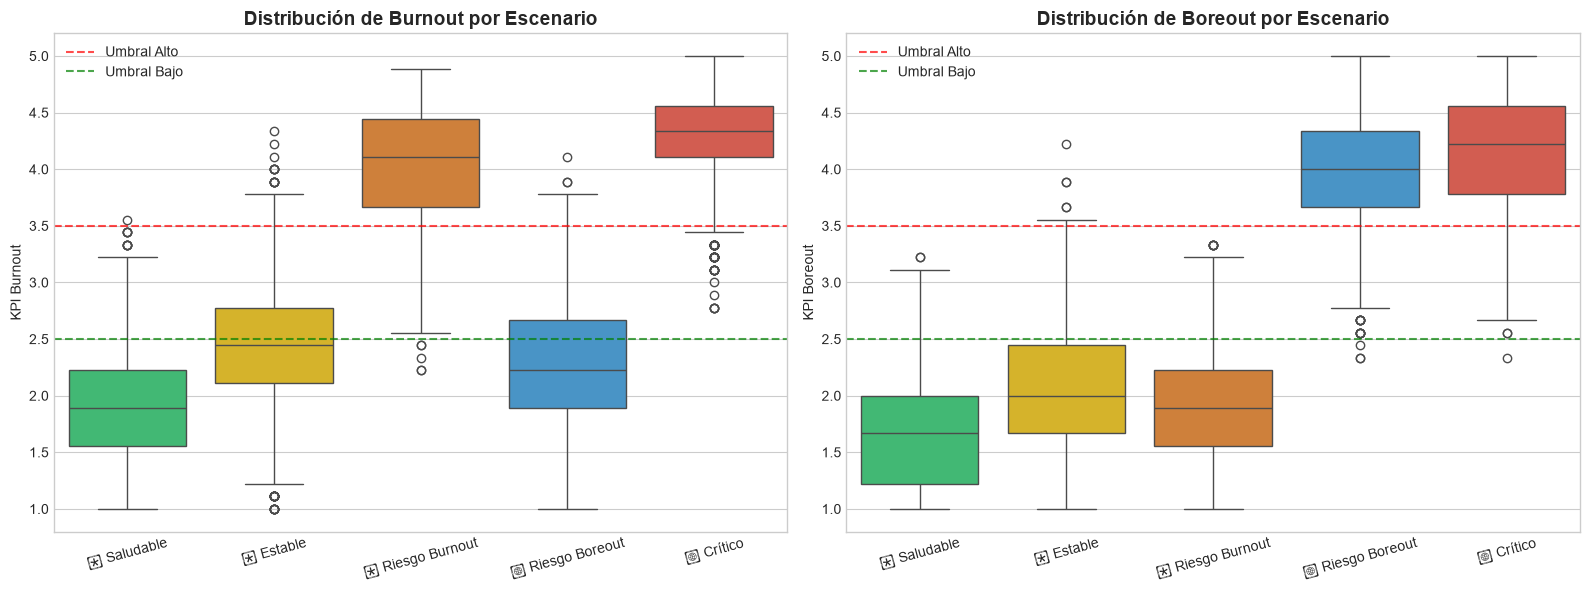


💡 INTERPRETACIÓN:
- Burnout: Alto en Riesgo Burnout y Crítico, bajo en Saludable y Boreout
- Boreout: Alto en Riesgo Boreout y Crítico, bajo en Saludable y Burnout
- El escenario Crítico tiene AMBOS problemas altos (dual risk)
- Los whiskers y outliers indican la variabilidad interna de cada escenario



In [5]:
# =====================================================
# GRÁFICO 2: BOXPLOTS DE BURNOUT Y BOREOUT
# =====================================================

# Crear paleta con etiquetas completas
PALETA_ETIQUETAS = {ETIQUETAS[esc]: COLORES[esc] for esc in ESCENARIOS}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Boxplot Burnout
sns.boxplot(data=df_all, x="escenario_label", y="kpi_burnout", 
            palette=PALETA_ETIQUETAS, ax=axes[0])
axes[0].set_title("Distribución de Burnout por Escenario", fontsize=14, fontweight='bold')
axes[0].set_xlabel("")
axes[0].set_ylabel("KPI Burnout")
axes[0].axhline(y=3.5, color='red', linestyle='--', alpha=0.7, label='Umbral Alto')
axes[0].axhline(y=2.5, color='green', linestyle='--', alpha=0.7, label='Umbral Bajo')
axes[0].legend()
axes[0].tick_params(axis='x', rotation=15)

# Boxplot Boreout
sns.boxplot(data=df_all, x="escenario_label", y="kpi_boreout",
            palette=PALETA_ETIQUETAS, ax=axes[1])
axes[1].set_title("Distribución de Boreout por Escenario", fontsize=14, fontweight='bold')
axes[1].set_xlabel("")
axes[1].set_ylabel("KPI Boreout")
axes[1].axhline(y=3.5, color='red', linestyle='--', alpha=0.7, label='Umbral Alto')
axes[1].axhline(y=2.5, color='green', linestyle='--', alpha=0.7, label='Umbral Bajo')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

print("""
💡 INTERPRETACIÓN:
- Burnout: Alto en Riesgo Burnout y Crítico, bajo en Saludable y Boreout
- Boreout: Alto en Riesgo Boreout y Crítico, bajo en Saludable y Burnout
- El escenario Crítico tiene AMBOS problemas altos (dual risk)
- Los whiskers y outliers indican la variabilidad interna de cada escenario
""")

### Gráfico 3: Stacked Bar - Proporción de empleados en riesgo

In [6]:
# =====================================================
# GRÁFICO 3: PROPORCIÓN DE EMPLEADOS EN RIESGO
# =====================================================

# Clasificar empleados según umbrales
def clasificar_empleado(row):
    if row["kpi_burnout"] >= 3.5 and row["kpi_boreout"] >= 3.5:
        return "Riesgo Dual (Burnout+Boreout)"
    elif row["kpi_burnout"] >= 3.5:
        return "Riesgo Burnout"
    elif row["kpi_boreout"] >= 3.5:
        return "Riesgo Boreout"
    else:
        return "Sin Riesgo"

df_all["estado_riesgo"] = df_all.apply(clasificar_empleado, axis=1)

# Calcular proporciones
proporciones = df_all.groupby(["escenario_label", "estado_riesgo"]).size().unstack(fill_value=0)
proporciones_pct = proporciones.div(proporciones.sum(axis=1), axis=0) * 100

# Reordenar categorías
orden_riesgo = ["Sin Riesgo", "Riesgo Burnout", "Riesgo Boreout", "Riesgo Dual (Burnout+Boreout)"]
colores_riesgo = {"Sin Riesgo": "#2ecc71", "Riesgo Burnout": "#e67e22", 
                  "Riesgo Boreout": "#3498db", "Riesgo Dual (Burnout+Boreout)": "#e74c3c"}

fig = px.bar(proporciones_pct[orden_riesgo], 
             barmode='stack',
             color_discrete_map=colores_riesgo,
             title="👥 Proporción de Empleados en Riesgo por Escenario (%)",
             labels={"value": "Porcentaje (%)", "variable": "Estado de Riesgo"})

fig.update_layout(height=500, xaxis_tickangle=-15)
fig.show()

print("""
💡 INTERPRETACIÓN:
- Escenario Saludable: ~90% sin riesgo, pocos casos problemáticos
- Escenario Estable: ~60-70% sin riesgo, riesgos moderados
- Riesgo Burnout: >60% con burnout alto, pocos con boreout
- Riesgo Boreout: >60% con boreout alto, pocos con burnout
- Crítico: Alto % con riesgo dual (ambos problemas simultáneos)
""")


💡 INTERPRETACIÓN:
- Escenario Saludable: ~90% sin riesgo, pocos casos problemáticos
- Escenario Estable: ~60-70% sin riesgo, riesgos moderados
- Riesgo Burnout: >60% con burnout alto, pocos con boreout
- Riesgo Boreout: >60% con boreout alto, pocos con burnout
- Crítico: Alto % con riesgo dual (ambos problemas simultáneos)



### Gráfico 4: Heatmap de Correlaciones

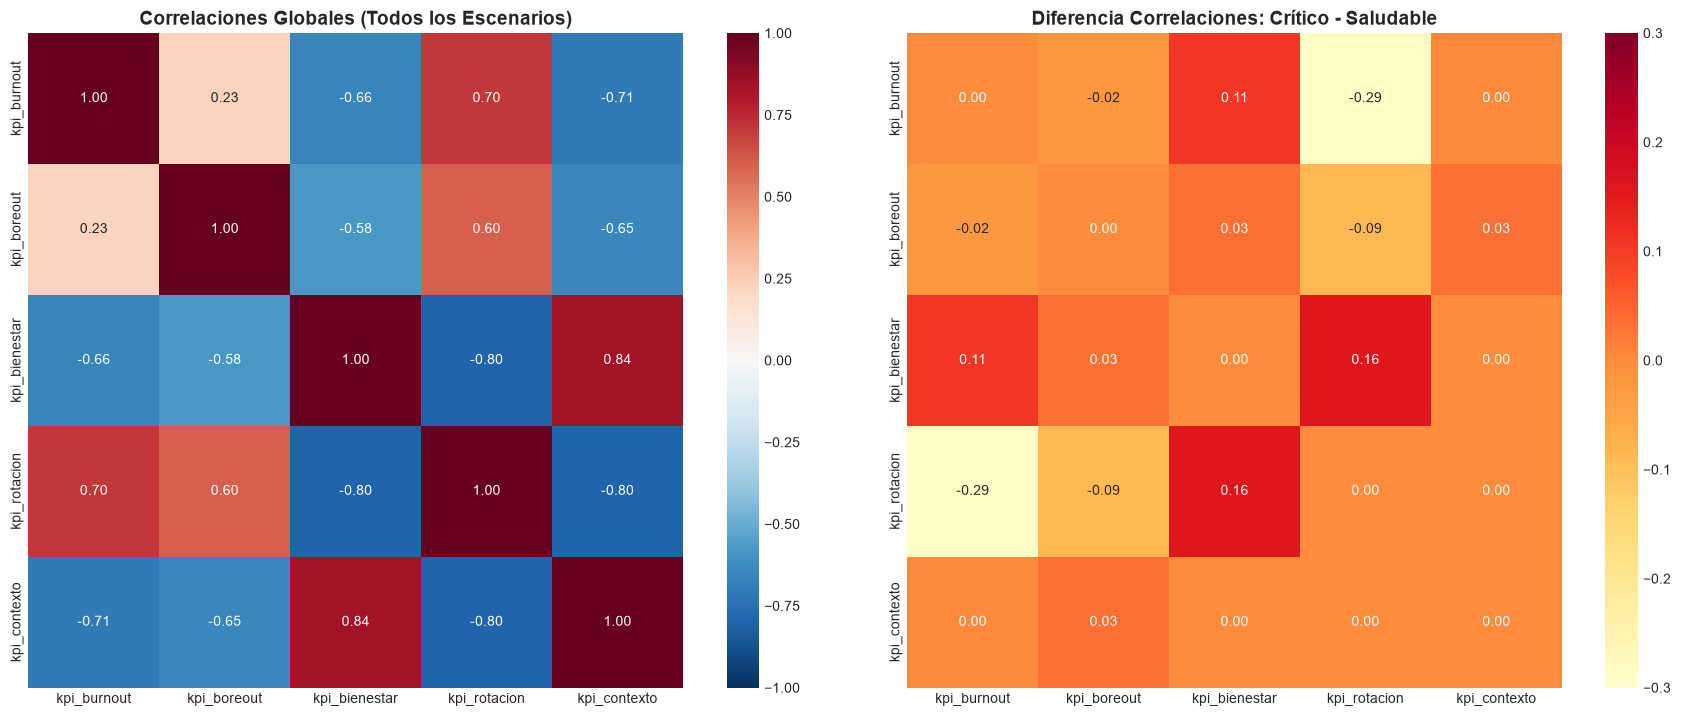


💡 INTERPRETACIÓN:
- Burnout y Bienestar tienen correlación negativa fuerte (esperado teóricamente)
- Boreout y Bienestar también negativamente correlacionados
- Burnout y Boreout pueden correlacionar positivamente en el escenario Crítico
- Las diferencias entre escenarios revelan cómo cambian los patrones psicológicos
  según el contexto organizacional



In [7]:
# =====================================================
# GRÁFICO 4: HEATMAP DE CORRELACIONES
# =====================================================

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Heatmap general
corr_all = df_all[KPIS].corr()
sns.heatmap(corr_all, annot=True, cmap='RdBu_r', center=0, 
            vmin=-1, vmax=1, fmt='.2f', ax=axes[0], square=True)
axes[0].set_title("Correlaciones Globales (Todos los Escenarios)", 
                  fontsize=14, fontweight='bold')

# Comparación de correlaciones por escenario (saludable vs crítico)
corr_saludable = dfs["saludable"][KPIS].corr()
corr_critico = dfs["critico"][KPIS].corr()
diferencia = corr_critico - corr_saludable

sns.heatmap(diferencia, annot=True, cmap='YlOrRd', center=0,
            vmin=-0.3, vmax=0.3, fmt='.2f', ax=axes[1], square=True)
axes[1].set_title("Diferencia Correlaciones: Crítico - Saludable",
                  fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("""
💡 INTERPRETACIÓN:
- Burnout y Bienestar tienen correlación negativa fuerte (esperado teóricamente)
- Boreout y Bienestar también negativamente correlacionados
- Burnout y Boreout pueden correlacionar positivamente en el escenario Crítico
- Las diferencias entre escenarios revelan cómo cambian los patrones psicológicos
  según el contexto organizacional
""")

### Gráfico 5: Scatter Plot - Mapa Burnout vs Boreout

In [8]:
# =====================================================
# GRÁFICO 5: SCATTER BURNOUT vs BOREOUT (MAPA DE POSICIONAMIENTO)
# =====================================================

# Muestra representativa para visualización
df_sample = df_all.sample(n=3000, random_state=42)

fig = px.scatter(
    df_sample,
    x="kpi_burnout",
    y="kpi_boreout",
    color="escenario_label",
    color_discrete_map=COLORES,
    hover_data=["departamento", "modalidad", "seniority"],
    opacity=0.6,
    title="🗺️ Mapa de Posicionamiento: Burnout vs Boreout",
    labels={"kpi_burnout": "Burnout", "kpi_boreout": "Boreout"}
)

# Añadir líneas de umbral
fig.add_hline(y=3.5, line_dash="dash", line_color="red", opacity=0.5)
fig.add_hline(y=2.5, line_dash="dash", line_color="green", opacity=0.5)
fig.add_vline(x=3.5, line_dash="dash", line_color="red", opacity=0.5)
fig.add_vline(x=2.5, line_dash="dash", line_color="green", opacity=0.5)

# Añadir etiquetas de cuadrantes
fig.add_annotation(x=4.2, y=4.5, text="🔴 CRÍTICO", showarrow=False, font_size=14)
fig.add_annotation(x=4.2, y=1.5, text="🟠 BURNOUT", showarrow=False, font_size=14)
fig.add_annotation(x=1.5, y=4.5, text="🔵 BOREOUT", showarrow=False, font_size=14)
fig.add_annotation(x=1.5, y=1.5, text="🟢 SALUDABLE", showarrow=False, font_size=14)

fig.update_layout(height=600)
fig.show()

print("""
💡 INTERPRETACIÓN:
- Los 4 cuadrantes representan los 4 estados organizacionales puros
- Cada escenario se posiciona claramente en su cuadrante esperado
- El escenario Crítico ocupa la esquina superior derecha (alto en ambos)
- Útil para ubicar a cualquier empresa/empleado en el espectro
""")


💡 INTERPRETACIÓN:
- Los 4 cuadrantes representan los 4 estados organizacionales puros
- Cada escenario se posiciona claramente en su cuadrante esperado
- El escenario Crítico ocupa la esquina superior derecha (alto en ambos)
- Útil para ubicar a cualquier empresa/empleado en el espectro



### Gráfico 6: KPIs por Colectivos (Género, Modalidad, Seniority)

In [9]:
# =====================================================
# GRÁFICO 6: KPIs POR COLECTIVOS
# =====================================================

fig = make_subplots(
    rows=1, cols=3,
    subplot_titles=("Por Género", "Por Modalidad", "Por Seniority"),
    specs=[[{"type": "bar"}, {"type": "bar"}, {"type": "bar"}]]
)

# 6a: Por género
by_gender = df_all.groupby("genero")[["kpi_burnout", "kpi_boreout", "kpi_bienestar"]].mean()
for i, kpi in enumerate(["kpi_burnout", "kpi_boreout", "kpi_bienestar"]):
    fig.add_trace(
        go.Bar(name=kpi.replace("kpi_", "").title(), x=by_gender.index, y=by_gender[kpi],
               showlegend=(i==0)),
        row=1, col=1
    )

# 6b: Por modalidad
by_mod = df_all.groupby("modalidad")[["kpi_burnout", "kpi_boreout", "kpi_bienestar"]].mean()
for i, kpi in enumerate(["kpi_burnout", "kpi_boreout", "kpi_bienestar"]):
    fig.add_trace(
        go.Bar(name=kpi.replace("kpi_", "").title(), x=by_mod.index, y=by_mod[kpi],
               showlegend=False),
        row=1, col=2
    )

# 6c: Por seniority
by_sen = df_all.groupby("seniority")[["kpi_burnout", "kpi_boreout", "kpi_bienestar"]].mean()
orden_sen = ["Junior", "Mid", "Senior", "Lead"]
by_sen = by_sen.loc[orden_sen]
for i, kpi in enumerate(["kpi_burnout", "kpi_boreout", "kpi_bienestar"]):
    fig.add_trace(
        go.Bar(name=kpi.replace("kpi_", "").title(), x=by_sen.index, y=by_sen[kpi],
               showlegend=False),
        row=1, col=3
    )

fig.update_layout(
    title_text="👥 KPIs por Colectivos Organizacionales",
    barmode='group',
    height=500
)
fig.show()

print("""
💡 INTERPRETACIÓN:
- Género: Permite detectar sesgos o diferencias en experiencia laboral
- Modalidad: Compara presencial vs híbrido vs remoto
- Seniority: Revela si los problemas afectan más a juniors, seniors o leads
""")


💡 INTERPRETACIÓN:
- Género: Permite detectar sesgos o diferencias en experiencia laboral
- Modalidad: Compara presencial vs híbrido vs remoto
- Seniority: Revela si los problemas afectan más a juniors, seniors o leads



## 📝 Conclusiones del EDA

### Hallazgos clave:
1. ✅ Los 5 escenarios están bien diferenciados
2. ✅ Los KPIs capturan los constructos teóricos esperados
3. ✅ Las correlaciones son coherentes con la literatura
4. ⚠️ [Añadir observaciones específicas de tus datos]

### Próximos pasos:
- `02_Analisis_profundo.ipynb`: Análisis inferencial y segmentación
- `03_Clustering.ipynb`: Identificación de perfiles de empleados